# Exploratory Data Analysis

## Outline

- Random Variable: A phenomenon whose outcome is not yet known
- Statistics, Machine Learning: Guessing future values of a phenomenon, based on past observations
- Exploratory Data Analysis: Discovering basic features of variables

1. Analyze categorical/numeric variables: Mean/standard deviation, median/IQR, 
2. Analyze pairs of categorical/numeric variables

# 1. Single Variables

## Recall: Getting to Know a Variable
- Current data type, `df[var].dtype`
- Number of missings, `df[var].isna().sum()`
- Unique values it takes, `df[var].unique()`
- Counts associated with unique values, `df[var].value_counts()`
- Histogram of the value counts, `df[var].hist( bins = 35 )`

> From this, you should be able to decide whether the variable is clean enough to proceed; otherwise, go back and clean it again

object
0
['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'Blueste' 'Mitchel' 'Timber' 'MeadowV' 'Veenker' 'GrnHill' 'Landmrk']
Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Mitchel    114
BrkSide    108
Crawfor    103
IDOTRR      93
Timber      72
NoRidge     71
StoneBr     51
SWISU       48
ClearCr     44
MeadowV     37
BrDale      30
Blmngtn     28
Veenker     24
NPkVill     23
Blueste     10
Greens       8
GrnHill      2
Landmrk      1
Name: count, dtype: int64


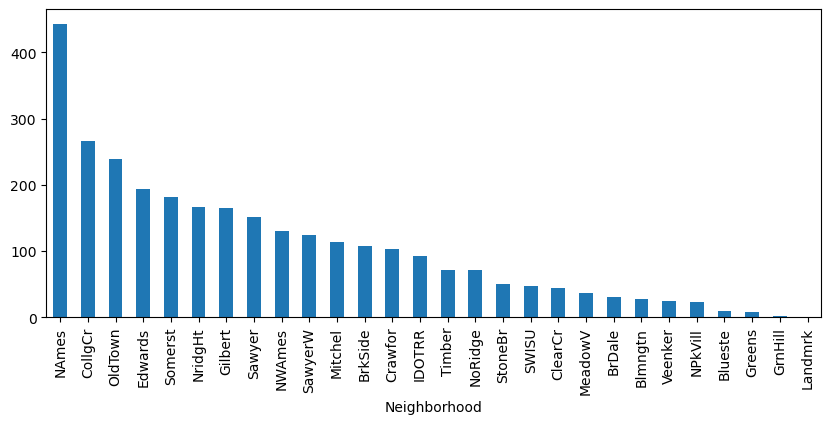

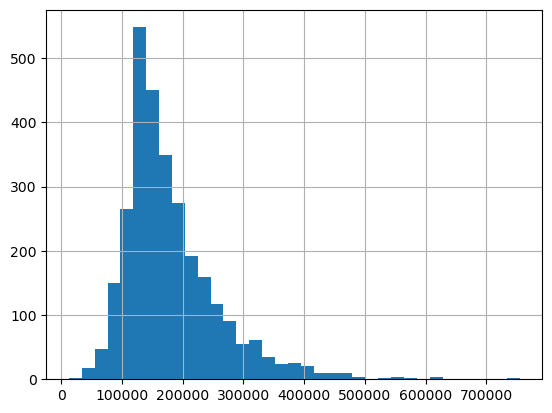

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/ames_prices.csv')

var = 'Neighborhood'

print(df[var].dtype)
print(df[var].isna().sum())
print(df[var].unique())
print(df[var].value_counts())
df[var].value_counts().plot(kind='bar', figsize=(10,4))
plt.show()

num = 'price'
df[num].hist(bins=35)
plt.show()

## Statistics
- A **statistic** is a function that maps data into a number
    - Proportion: What proportion of observations take a particular label?
    - Mean: What is the average of the recorded values of the variable?

## Analyzing a Categorical
- Analyzing a categorical variable $C$ is about computing how often it takes each possible label $\ell$: How are the data spread out across labels?

- A **sample proportion** is the fraction of observations taking the value $\ell$

- Proportions of labels, among non-missing values: 
    - `df[var].value_counts(normalize=True)`
- Proportions of labels, including missing values as an additional category: 
    - `df[var].value_counts(normalize=True, dropna=False)`

- Bar/count plot for visualization: 
    - `sns.countplot(x=df[var],stat='proportion')`
    - `sns.countplot(data=df, x=var, stat='proportion')`

Bldg.Type
1Fam      0.827645
TwnhsE    0.079522
Duplex    0.037201
Twnhs     0.034471
2fmCon    0.021160
Name: proportion, dtype: float64
Bldg.Type
1Fam      0.827645
TwnhsE    0.079522
Duplex    0.037201
Twnhs     0.034471
2fmCon    0.021160
Name: proportion, dtype: float64


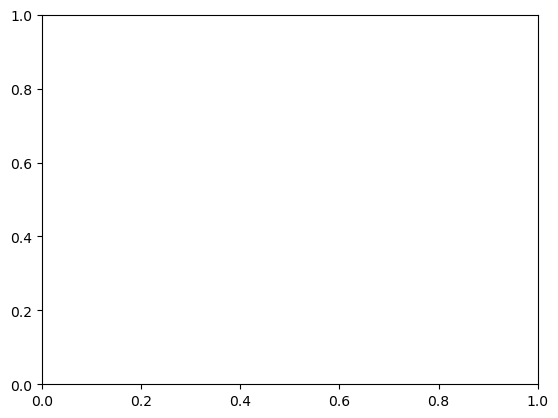

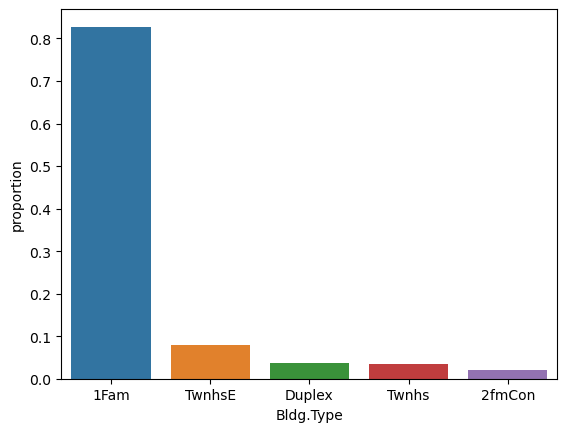

In [4]:
# Analyzing a categorical variable: Bldg.Type
print(df['Bldg.Type'].value_counts(normalize=True))
print(df['Bldg.Type'].value_counts(normalize=True, dropna=False))

try:
    sns.countplot(data=df, x='Bldg.Type', stat='proportion')
except (TypeError, AttributeError):
    # older seaborn versions do not support the `stat` argument
    plt.figure()
    props = df['Bldg.Type'].value_counts(normalize=True)
    sns.barplot(x=props.index, y=props.values)
    plt.ylabel('proportion')
plt.show()

## Analyzing a Numeric

- Analyzing a numeric variable $x$ is about computing how of: How are the data spread out across numeric values?
- To visualize the variable, `sns.histplot( df[var], bins=50)`
- For basic numeric summary, `df[var].describe()`


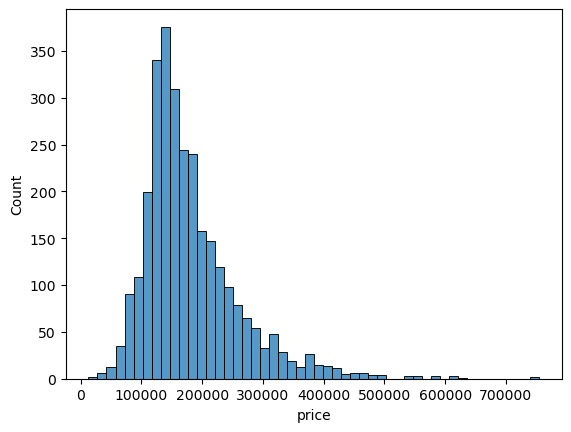

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: price, dtype: float64

In [5]:
# Analyzing a numeric variable: price
sns.histplot(df['price'], bins=50)
plt.show()

df['price'].describe()

## Mean and Variance

- How disperse is your variable, $X = (x_1, ... , x_n)$?
- The **sample mean** is a standard measure of central tendency, the arithmetic average of the data:
$$
M(X) = \dfrac{x_1 + x_2 + ... + x_n}{n} = \frac{1}{n} \sum_{i=1}^n x_i
$$
- The **sample variance** is the arithmetic average of sum of squares of the observations from the mean,
$$
V(X) = \dfrac{1}{n} \sum_{i=1}^n (x_i - M(X))^2
$$
- The **sample standard deviation** is the square root of sample variance: $\text{sd}(x) = \sqrt{V(X)}$

In [6]:
# Mean and variance/std of price
mean_price = df['price'].mean()
var_price = df['price'].var(ddof=0)
sd_price = df['price'].std(ddof=0)

print('Mean:', mean_price)
print('Variance:', var_price)
print('Std Dev:', sd_price)

Mean: 180796.0600682594
Variance: 6379705498.413448
Std Dev: 79873.05865192247


## Median

- The mean and variance are particular sensitive to **outliers**: Values that are atypically high or low, and exert a lot of leverage on $M(X)$ and $V(X)$
- **Robust statistics** is the study of estimators that are less sensitive to outliers
- The **sample median** is a robust measure of central tendency, and corresponds to the value of $X$ for which half the data are above it, and half the data are below it:

$$\mathrm{med}(x) = \begin{cases}
x_{\left(\frac{n+1}{2}\right)} & n \text{ odd} \\[4pt]
\tfrac{1}{2}\left(x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}\right) & n \text{ even}
\end{cases}$$

- `df['var'].med()`

In [7]:
# Median vs mean, showing sensitivity to outliers
print('Median price:', df['price'].median())
print('Mean price:', df['price'].mean())

Median price: 160000.0
Mean price: 180796.0600682594


## Quantiles

- The median targets "this is the value for which half of the sample is below, and half of the sample is above"
- What if said, "I want to find the value for which a proportion $f$ of the sample is below, and $(1-f)%$ of the sample is above"
- This is called the **$f$-th quantile**:
  
$$x_{(1)} \le x_{(2)} \le \cdots \le x_{(n)}, \qquad \hat q_f = x_{(\lceil n f \rceil)}$$

- `np.quantile(X,f)`

In [8]:
# Quantiles of price
for f in [0.1, 0.25, 0.5, 0.75, 0.9]:
    print(f, np.quantile(df['price'], f))

0.1 105450.00000000001
0.25 129500.0
0.5 160000.0
0.75 213500.0
0.9 281241.69999999995


## Two Useful Transformations
- Almost every dataset I have ever opened has a few data with **long tails**: The mean is much larger or smaller than the median, because the data have a very small number of very large values
- To visualize and numerically stabilize these kinds of variables, we often take the **natural logarithm**, `df['var_ln'] = np.log(df[var])`
    - The natural log has two problems: At zero it goes to $-\infty$ and it is not defined for negative numbers
- The better choice is called the **inverse hyperbolic sine** or **arcinsh**, `df['var_ihs'] = np.arcsinh(df[var])`:
$$
i(x) = \ln \left( x + \sqrt{x^2+1} \right) 
$$
- This is defined for positive and negative values and takes the value zero at zero


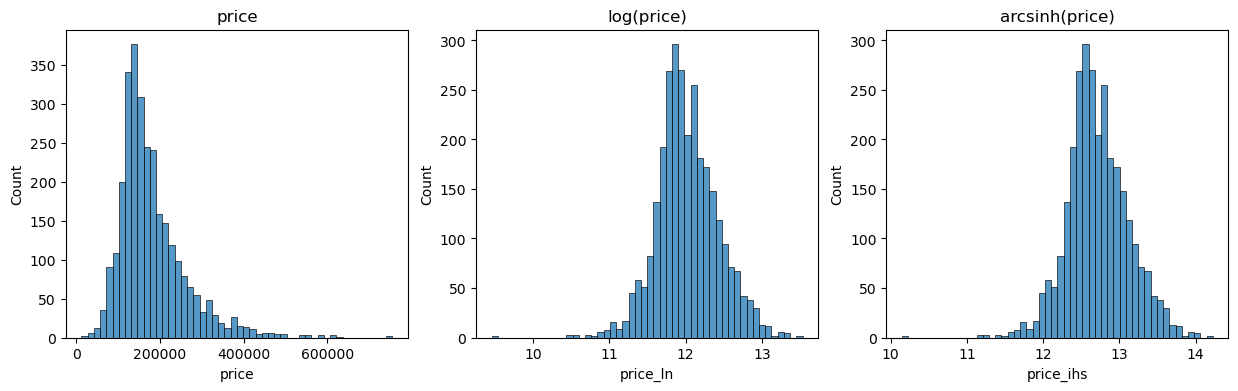

In [9]:
# Log and IHS transformations of price
df['price_ln'] = np.log(df['price'])
df['price_ihs'] = np.arcsinh(df['price'])

fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['price'], bins=50, ax=axes[0]).set_title('price')
sns.histplot(df['price_ln'], bins=50, ax=axes[1]).set_title('log(price)')
sns.histplot(df['price_ihs'], bins=50, ax=axes[2]).set_title('arcsinh(price)')
plt.show()

# 2. Pairs of Variables

## Pairs of Categoricals

- To break out counts by two categoricals at the same time, we use a **contingency table** or **cross-tabulation**: `pd.crosstab(df[var1], df[var2])`
- This provides the joint counts for two categorical variables, allowing us to see how they vary together or not

In [10]:
# Contingency table: Bldg.Type vs Central.Air
pd.crosstab(df['Bldg.Type'], df['Central.Air'])

Central.Air,N,Y
Bldg.Type,,
1Fam,143,2282
2fmCon,28,34
Duplex,25,84
Twnhs,0,101
TwnhsE,0,233


## Pairs of Numerics

- How do we visualize the relationship between two variables?
- The numeric version of a contingency table is a scatterplot: `sns.scatterplot( x = df[var1], y=df[var2], alpha = .15 )`
- We often want to summarize that picture with a number, and typically use
$$
\text{cov}(X,Y) = \frac{\sum_{i=1}^n (x_i - M(X))(y_i - M(Y))}{n}
$$

- This can easily be computed: `df[[var1, var2]].cov()`

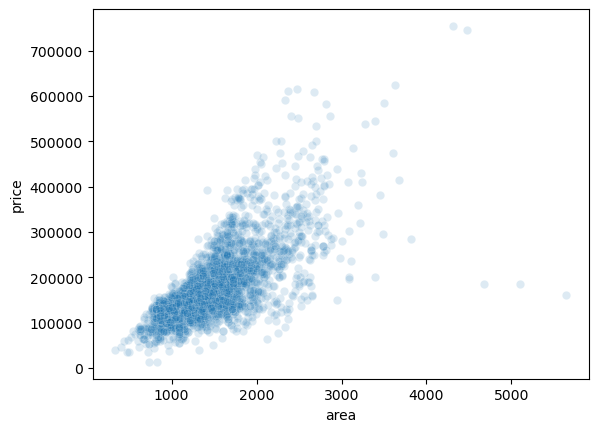

,area,price
area,2.555392e+05,2.854220e+07
price,2.854220e+07,6.381884e+09


In [11]:
# Pairs of numerics: area vs price
sns.scatterplot(x=df['area'], y=df['price'], alpha=.15)
plt.show()

df[['area', 'price']].cov()

## Numeric by Categorical

- To **conditional** analysis of a numeric variable `num` on a categorical variable `cat`, we perform an analysis on subgroups of the data determined by their labelling
- To visualize a numeric conditional on a categorical, you can use `hue`: `sns.kdeplot( x = df[num], hue = df[cat], fill=True)`

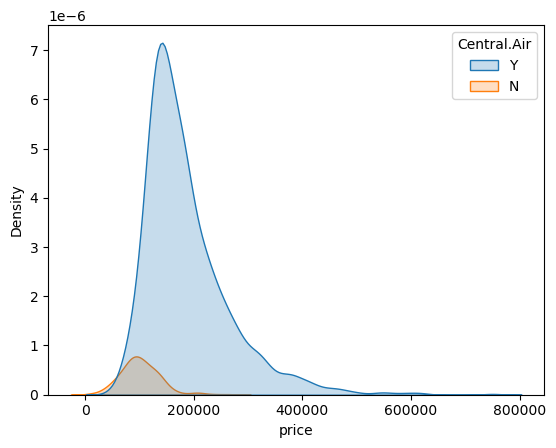

In [12]:
# Numeric conditional on categorical: price by Central.Air
sns.kdeplot(x=df['price'], hue=df['Central.Air'], fill=True)
plt.show()

## Groupby
- A general description by groups: 
    - `df[[cat,num]].groupby(cat).describe()`
- Specific statistics: `df[[cat,num]].groupby(cat).count()` or `.mean()`, `.sum()`, `.count()`, etc.
- For a custom function, `fcn()`: `df[[cat,num]].groupby(cat).agg(fcn)`
- Some useful options:
    - `.nlargest(K)` returns the $K$ largest values

In [13]:
# Groupby examples
display(df[['Bldg.Type','price']].groupby('Bldg.Type').describe())

print(df[['Bldg.Type','price']].groupby('Bldg.Type').mean())

def price_range(x):
    return x.max() - x.min()

print(df[['Bldg.Type','price']].groupby('Bldg.Type').agg(price_range))

df[['Bldg.Type','price']].groupby('Bldg.Type').mean().nlargest(3, 'price')

price                                                            \
            count           mean           std      min       25%       50%   
Bldg.Type                                                                     
1Fam       2425.0  184812.041237  82821.802329  12789.0  130000.0  165000.0   
2fmCon       62.0  125581.709677  31089.239840  55000.0  106562.5  122250.0   
Duplex      109.0  139808.935780  39498.973534  61500.0  118858.0  136905.0   
Twnhs       101.0  135934.059406  41938.931130  73000.0  100500.0  130000.0   
TwnhsE      233.0  192311.914163  66191.738021  71000.0  145000.0  180000.0   

                               
                75%       max  
Bldg.Type                      
1Fam       220000.0  755000.0  
2fmCon     140000.0  228950.0  
Duplex     153337.0  269500.0  
Twnhs      170000.0  280750.0  
TwnhsE     222000.0  392500.0

                   price
Bldg.Type               
1Fam       184812.041237
2fmCon     125581.709677
Duplex     139808.935780
Twnhs      135934.059406
TwnhsE     192311.914163
            price
Bldg.Type        
1Fam       742211
2fmCon     173950
Duplex     208000
Twnhs      207750
TwnhsE     321500


,price
Bldg.Type,
TwnhsE,192311.914163
1Fam,184812.041237
Duplex,139808.935780
